In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

In [21]:
BASE_DIR = Path.cwd()
RAW_DATA_PATH = BASE_DIR.parent / "DataSet" / "Raw" / "data.csv"

COL_PRICE = "price_in_euro"
COL_KM    = "mileage_in_km"
COL_YEAR  = "year"
COL_BRAND = "brand"
COL_FUEL  = "fuel_type"

df = pd.read_csv(RAW_DATA_PATH)

df[COL_PRICE] = pd.to_numeric(df[COL_PRICE], errors="coerce")
df[COL_KM]    = pd.to_numeric(df[COL_KM],    errors="coerce")
df[COL_YEAR]  = pd.to_numeric(df[COL_YEAR],  errors="coerce")

df = df[(df[COL_PRICE] > 500) & (df[COL_PRICE] <= 100_000)]
df = df[(df[COL_KM]    > 0)   & (df[COL_KM]    <= 500_000)]
df = df[(df[COL_YEAR]  >= 1990)]

print(f"Redova nakon čišćenja: {len(df):,}")

Redova nakon čišćenja: 245,485


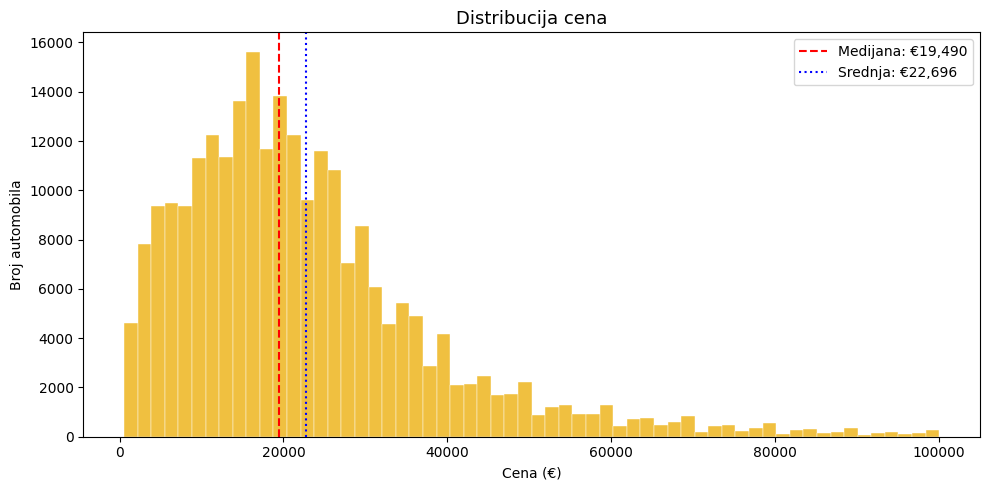

In [22]:
# ── Histogram - Distribucija cene ────────────────────────────────
prices = pd.to_numeric(df["price_in_euro"], errors="coerce").dropna()
prices = prices[(prices > 0) & (prices <= 100_000)]

plt.figure(figsize=(10, 5))
plt.hist(prices, bins=60, color="#f0c040", edgecolor="white", linewidth=0.3)

plt.axvline(prices.median(), color="red", linestyle="--", label=f"Medijana: €{prices.median():,.0f}")
plt.axvline(prices.mean(),   color="blue", linestyle=":",  label=f"Srednja: €{prices.mean():,.0f}")

plt.title("Distribucija cena", fontsize=13)
plt.xlabel("Cena (€)")
plt.ylabel("Broj automobila")
plt.legend()
plt.tight_layout()
plt.show()

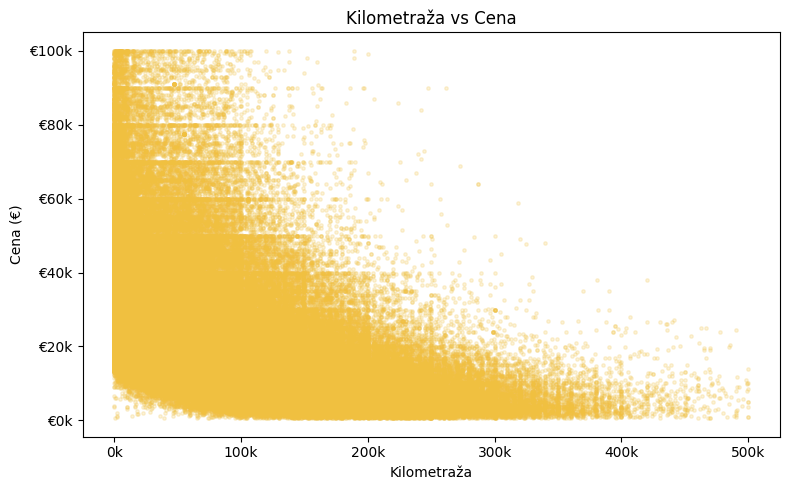

In [29]:
# ── Scatter — kilometraža vs cena ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df[COL_KM], df[COL_PRICE], alpha=0.2, s=6, color="#f0c040")
ax.set_xlabel("Kilometraža")
ax.set_ylabel("Cena (€)")
ax.set_title("Kilometraža vs Cena")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
plt.tight_layout()
plt.show()

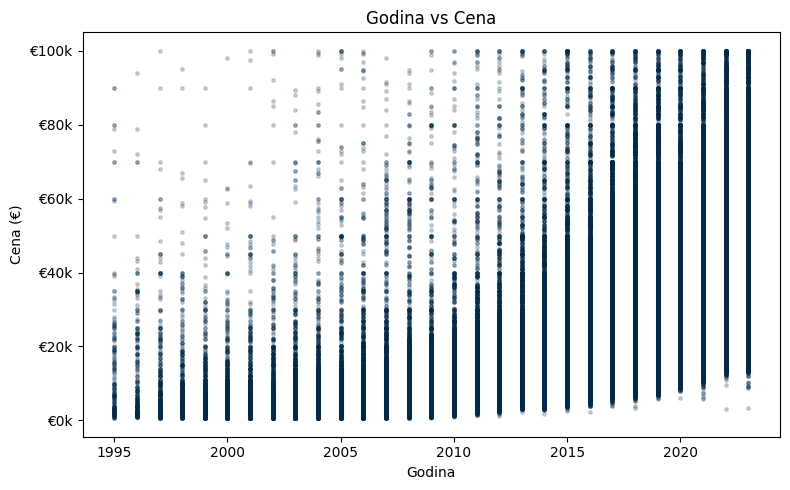

In [24]:
# ── Scatter — godina vs cena ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df[COL_YEAR], df[COL_PRICE], alpha=0.2, s=6, color="#002a4b")
ax.set_xlabel("Godina")
ax.set_ylabel("Cena (€)")
ax.set_title("Godina vs Cena")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
plt.tight_layout()
plt.show()

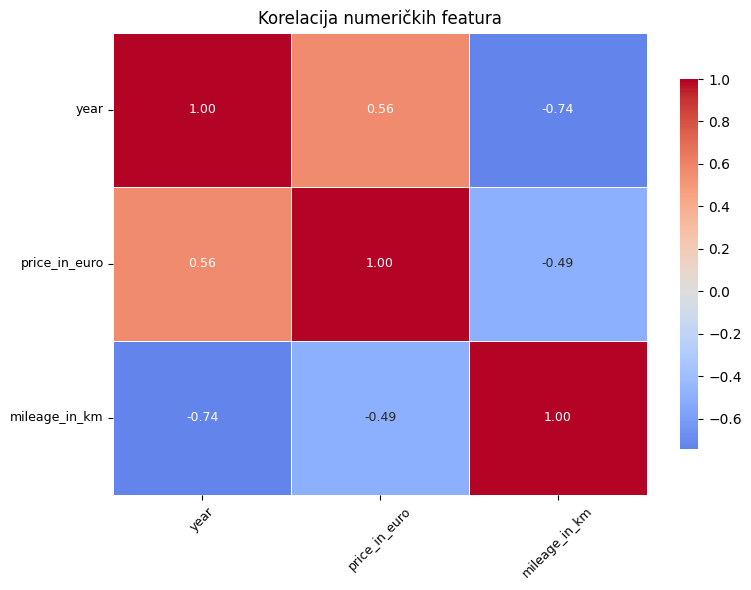

In [25]:
# ── Heatmapa korelacija ────────────────────────────────────────────
num_cols = df.select_dtypes(include="number").dropna(axis=1, how="all").columns.tolist()
num_cols = [c for c in num_cols if not c.lower().startswith("unnamed")]
corr = df[num_cols].corr()
 
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, ax=ax, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Korelacija numeričkih featura")
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

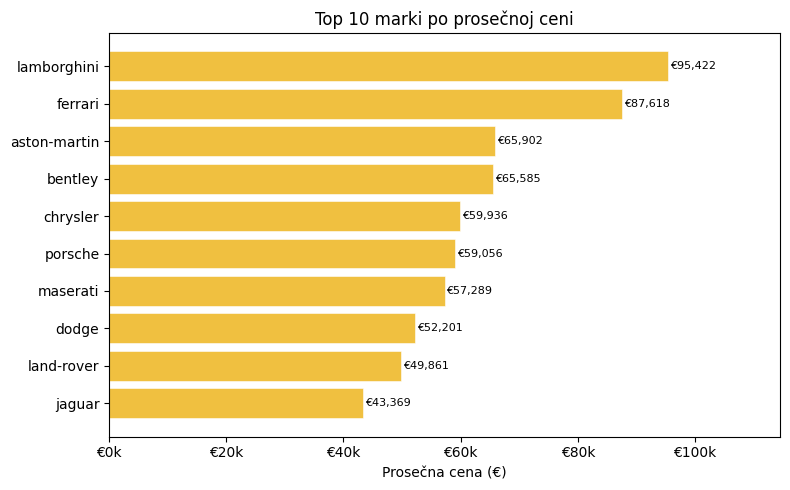

In [26]:
# ── Top 10 marki po prosečnoj ceni ───────────────────────────────
top10 = (
    df.groupby(COL_BRAND)[COL_PRICE]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
 
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(top10.index[::-1], top10.values[::-1], color="#f0c040", edgecolor="white", linewidth=0.4)
for bar, val in zip(bars, top10.values[::-1]):
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height() / 2,
            f"€{val:,.0f}", va="center", fontsize=8)
ax.set_xlabel("Prosečna cena (€)")
ax.set_title("Top 10 marki po prosečnoj ceni")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax.set_xlim(0, top10.max() * 1.2)
plt.tight_layout()
plt.show()

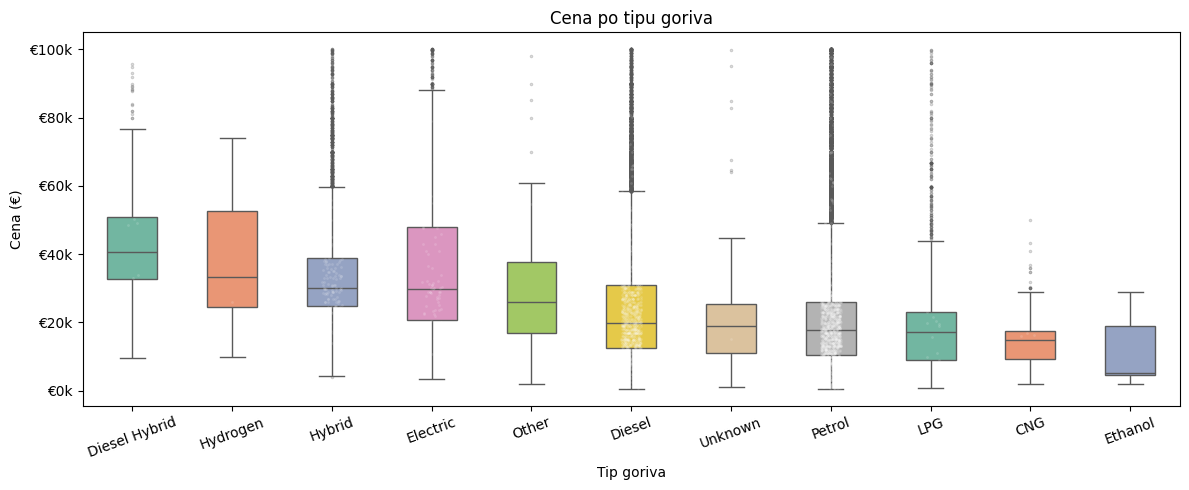

In [27]:
# ── Box + strip plot — cena po tipu goriva ───────────────────────
fuel_order = (
    df.groupby(COL_FUEL)[COL_PRICE].median()
    .sort_values(ascending=False).index.tolist()
)
 
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=df, x=COL_FUEL, y=COL_PRICE,
    hue=COL_FUEL,
    order=fuel_order,
    hue_order=fuel_order,
    ax=ax,
    palette="Set2",
    width=0.5,
    flierprops=dict(marker=".", alpha=0.3, markersize=3),
    legend=False
)
sns.stripplot(
    data=df.sample(min(3000, len(df)), random_state=42),
    x=COL_FUEL, y=COL_PRICE,
    order=fuel_order, ax=ax,
    color="white", alpha=0.15, size=2, jitter=True
)
ax.set_title("Cena po tipu goriva")
ax.set_xlabel("Tip goriva")
ax.set_ylabel("Cena (€)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

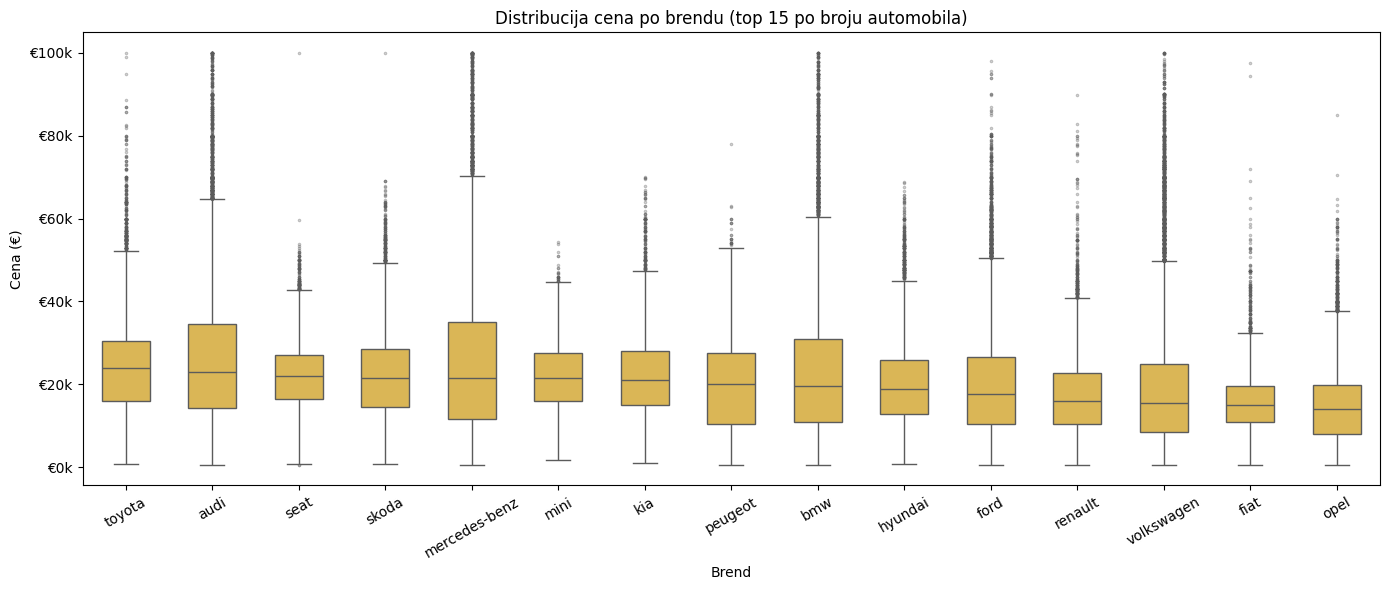

In [ ]:
# ── Box plot — cena po brendu (top 15) ───────────────────────────
top15_brands = df[COL_BRAND].value_counts().head(15).index.tolist()
df_top = df[df[COL_BRAND].isin(top15_brands)]

brand_order = (
    df_top.groupby(COL_BRAND)[COL_PRICE].median()
    .sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=df_top, x=COL_BRAND, y=COL_PRICE,
    order=brand_order, ax=ax,
    color="#f0c040", width=0.55,
    flierprops=dict(marker=".", color="#e06060", alpha=0.4, markersize=3)
)
ax.set_title("Distribucija cena po brendu (top 15 po broju automobila)")
ax.set_xlabel("Brend")
ax.set_ylabel("Cena (€)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()